# Snorkel weak supervision using schema-based financial statements

This notebook creates a **schema-aligned** financial statements dataset and applies **Snorkel** labeling functions to infer economic-cycle labels.

Economic-cycle label IDs:
- `0 = contraction`
- `1 = slowdown`
- `2 = expansion`
- `3 = recovery`

The generated CSV is saved in the same folder as this notebook.


## 1. Imports and setup

In [56]:
# If needed:
# %pip install snorkel pandas numpy scikit-learn

import numpy as np
import pandas as pd

from snorkel.labeling import labeling_function, PandasLFApplier, LFAnalysis
from snorkel.labeling.model import LabelModel
from sklearn.metrics import classification_report, confusion_matrix


## 2. Generate a 200-row schema-based statements dataset

Columns are selected directly from `SCHEMA_01_STATEMENTS.txt` and expressed as numeric annual values.


In [57]:
rng = np.random.default_rng(123)
n_per_phase = 50

PHASES = {0: "contraction", 1: "slowdown", 2: "expansion", 3: "recovery"}

# Schema-aligned columns (subset across Income Statement / Balance Sheet / Cash Flow)
SCHEMA_COLS = [
    "Total revenue",
    "Operating income",
    "Net income",
    "EBITDA",
    "EBIT",
    "Total operating expenses",
    "Total interest expense (banks)",
    "Taxes",
    "Total assets",
    "Total liabilities",
    "Total equity",
    "Net debt",
    "Cash and short term investments",
    "Total debt",
    "Net loans",
    "Loan loss allowances (reserves)",
    "Total deposits",
    "Cash from operating activities",
    "Cash from investing activities",
    "Cash from financing activities",
    "Capital expenditures",
    "Free cash flow",
    "Interest paid",
    "Taxes paid",
]

def build_phase_block(phase_id: int, n: int) -> pd.DataFrame:
    # Start from scale variables to maintain coherent accounting relationships.
    if phase_id == 0:  # contraction
        revenue = rng.normal(820, 90, n)
        opex_ratio = rng.normal(0.88, 0.04, n)
        interest = rng.normal(48, 8, n)
        tax_rate = rng.normal(0.17, 0.03, n)
        assets = rng.normal(2600, 260, n)
        liabilities = rng.normal(2220, 200, n)
        debt = rng.normal(980, 120, n)
        cash_st = rng.normal(220, 35, n)
        net_loans = rng.normal(1240, 140, n)
        loan_loss = rng.normal(68, 12, n)
        deposits = rng.normal(1280, 130, n)
        cfo = rng.normal(52, 22, n)
        cfi = rng.normal(-66, 20, n)
        cff = rng.normal(28, 18, n)
        capex = rng.normal(-44, 10, n)
        interest_paid = rng.normal(52, 7, n)
        taxes_paid = rng.normal(12, 4, n)
    elif phase_id == 1:  # slowdown
        revenue = rng.normal(980, 95, n)
        opex_ratio = rng.normal(0.82, 0.04, n)
        interest = rng.normal(43, 7, n)
        tax_rate = rng.normal(0.19, 0.03, n)
        assets = rng.normal(2750, 250, n)
        liabilities = rng.normal(2260, 190, n)
        debt = rng.normal(940, 110, n)
        cash_st = rng.normal(245, 40, n)
        net_loans = rng.normal(1320, 135, n)
        loan_loss = rng.normal(52, 10, n)
        deposits = rng.normal(1360, 120, n)
        cfo = rng.normal(96, 28, n)
        cfi = rng.normal(-78, 22, n)
        cff = rng.normal(8, 16, n)
        capex = rng.normal(-56, 12, n)
        interest_paid = rng.normal(46, 6, n)
        taxes_paid = rng.normal(22, 5, n)
    elif phase_id == 2:  # expansion
        revenue = rng.normal(1260, 110, n)
        opex_ratio = rng.normal(0.72, 0.04, n)
        interest = rng.normal(34, 6, n)
        tax_rate = rng.normal(0.23, 0.03, n)
        assets = rng.normal(2980, 270, n)
        liabilities = rng.normal(2300, 200, n)
        debt = rng.normal(860, 100, n)
        cash_st = rng.normal(295, 45, n)
        net_loans = rng.normal(1410, 145, n)
        loan_loss = rng.normal(34, 8, n)
        deposits = rng.normal(1450, 130, n)
        cfo = rng.normal(182, 34, n)
        cfi = rng.normal(-116, 26, n)
        cff = rng.normal(-18, 18, n)
        capex = rng.normal(-88, 16, n)
        interest_paid = rng.normal(37, 6, n)
        taxes_paid = rng.normal(41, 7, n)
    else:  # recovery
        revenue = rng.normal(1120, 100, n)
        opex_ratio = rng.normal(0.77, 0.04, n)
        interest = rng.normal(39, 7, n)
        tax_rate = rng.normal(0.21, 0.03, n)
        assets = rng.normal(2860, 260, n)
        liabilities = rng.normal(2280, 190, n)
        debt = rng.normal(900, 105, n)
        cash_st = rng.normal(270, 40, n)
        net_loans = rng.normal(1370, 140, n)
        loan_loss = rng.normal(44, 9, n)
        deposits = rng.normal(1410, 125, n)
        cfo = rng.normal(138, 30, n)
        cfi = rng.normal(-98, 24, n)
        cff = rng.normal(-2, 16, n)
        capex = rng.normal(-72, 14, n)
        interest_paid = rng.normal(41, 6, n)
        taxes_paid = rng.normal(31, 6, n)

    total_opex = revenue * opex_ratio
    operating_income = revenue - total_opex
    ebit = operating_income + rng.normal(0, 8, n)
    ebitda = ebit + np.abs(rng.normal(42, 10, n))
    pretax_income = ebit - interest + rng.normal(0, 6, n)
    taxes = np.maximum(pretax_income * tax_rate, 1.0)
    net_income = pretax_income - taxes
    equity = assets - liabilities
    net_debt = debt - cash_st
    free_cash_flow = cfo + capex

    df_p = pd.DataFrame({
        "Total revenue": np.round(revenue, 2),
        "Operating income": np.round(operating_income, 2),
        "Net income": np.round(net_income, 2),
        "EBITDA": np.round(ebitda, 2),
        "EBIT": np.round(ebit, 2),
        "Total operating expenses": np.round(total_opex, 2),
        "Total interest expense (banks)": np.round(np.abs(interest), 2),
        "Taxes": np.round(np.maximum(taxes, 0), 2),
        "Total assets": np.round(assets, 2),
        "Total liabilities": np.round(liabilities, 2),
        "Total equity": np.round(equity, 2),
        "Net debt": np.round(net_debt, 2),
        "Cash and short term investments": np.round(np.maximum(cash_st, 1), 2),
        "Total debt": np.round(np.maximum(debt, 1), 2),
        "Net loans": np.round(np.maximum(net_loans, 1), 2),
        "Loan loss allowances (reserves)": np.round(np.maximum(loan_loss, 0.1), 2),
        "Total deposits": np.round(np.maximum(deposits, 1), 2),
        "Cash from operating activities": np.round(cfo, 2),
        "Cash from investing activities": np.round(cfi, 2),
        "Cash from financing activities": np.round(cff, 2),
        "Capital expenditures": np.round(capex, 2),
        "Free cash flow": np.round(free_cash_flow, 2),
        "Interest paid": np.round(np.maximum(interest_paid, 0.1), 2),
        "Taxes paid": np.round(np.maximum(taxes_paid, 0.1), 2),
        "phase_true": phase_id,
    })
    return df_p

parts = [build_phase_block(pid, n_per_phase) for pid in [0, 1, 2, 3]]
df = pd.concat(parts, ignore_index=True).sample(frac=1.0, random_state=12).reset_index(drop=True)

print("Rows:", len(df))
print("Columns:", len(df.columns))
df.head(8)


Rows: 200
Columns: 25


,Total revenue,Operating income,Net income,EBITDA,EBIT,Total operating expenses,Total interest expense (banks),Taxes,Total assets,Total liabilities,...,Loan loss allowances (reserves),Total deposits,Cash from operating activities,Cash from investing activities,Cash from financing activities,Capital expenditures,Free cash flow,Interest paid,Taxes paid,phase_true
0,921.41,54.57,-2.22,90.09,49.24,866.85,50.03,1.00,3004.19,2233.69,...,61.32,1204.77,34.13,-58.39,8.60,-55.89,-21.77,52.59,15.43,0
1,1137.99,331.21,254.17,381.05,331.54,806.78,32.66,55.73,2481.85,2344.95,...,54.02,1510.58,158.78,-110.35,16.64,-85.15,73.62,19.60,30.87,3
2,947.56,240.11,153.87,264.16,233.48,707.45,37.28,30.59,2909.67,2430.65,...,53.80,1575.54,134.32,-48.06,-11.61,-75.31,59.00,37.59,22.28,3
3,894.51,94.32,54.24,146.89,104.39,800.19,45.95,9.48,2480.90,2286.96,...,42.88,1222.40,37.21,-65.79,6.97,-40.37,-3.16,52.18,14.33,0
4,946.77,122.97,74.45,153.73,121.61,823.80,27.74,14.72,2644.13,2215.96,...,36.76,1458.94,76.94,-60.62,-14.91,-51.56,25.37,46.99,14.37,1
5,682.67,97.17,47.53,132.45,87.16,585.49,34.51,9.31,2717.75,2126.69,...,47.64,977.74,75.63,-76.28,12.17,-67.37,8.26,44.16,2.57,0
6,1102.27,214.68,139.77,224.53,204.11,887.59,39.51,24.22,2519.70,1906.04,...,32.70,1399.78,123.96,-61.74,34.19,-73.82,50.13,47.81,10.68,1
7,930.36,50.54,12.71,110.87,56.42,879.82,42.35,2.72,2014.67,2143.95,...,68.79,1309.82,87.01,-73.61,44.44,-30.64,56.37,55.44,13.67,0


In [58]:
# Save CSV in same folder as notebook
csv_path = "snorkel_schema_statements_200.csv"
df.to_csv(csv_path, index=False)
print(f"Saved {csv_path}")


Saved snorkel_schema_statements_200.csv


## 3. Add engineered ratios for labeling functions

These features are derived from schema columns and help encode cycle heuristics.


In [59]:
df_w = df.copy()
df_w["profit_margin"] = df_w["Net income"] / df_w["Total revenue"]
df_w["opex_ratio"] = df_w["Total operating expenses"] / df_w["Total revenue"]
df_w["leverage_ratio"] = df_w["Total debt"] / df_w["Total equity"].clip(lower=1e-6)
df_w["loan_loss_to_loans"] = df_w["Loan loss allowances (reserves)"] / df_w["Net loans"].clip(lower=1e-6)
df_w["cfo_to_revenue"] = df_w["Cash from operating activities"] / df_w["Total revenue"].clip(lower=1e-6)

df_w[["profit_margin", "opex_ratio", "leverage_ratio", "loan_loss_to_loans", "cfo_to_revenue"]].describe().T


,count,mean,std,min,25%,50%,75%,max
profit_margin,200.0,1.274699e-01,6.271194e-02,-0.014900,0.074813,0.131767,0.178791,2.479717e-01
opex_ratio,200.0,7.980625e-01,7.085375e-02,0.634194,0.745818,0.795513,0.857803,9.481603e-01
leverage_ratio,200.0,7.362225e+07,2.524589e+08,0.564634,1.216956,1.801808,3.132055,1.156150e+09
loan_loss_to_loans,200.0,3.778317e-02,1.527259e-02,0.012415,0.026432,0.034461,0.047522,1.107852e-01
cfo_to_revenue,200.0,1.064005e-01,3.923059e-02,-0.009373,0.079112,0.110481,0.131751,2.008396e-01


## 4. Snorkel labels and labeling functions

In [60]:
ABSTAIN = -1
CONTRACTION = 0
SLOWDOWN = 1
EXPANSION = 2
RECOVERY = 3

@labeling_function()
def lf_contraction_losses(x):
    if x["profit_margin"] < 0.035 and x["loan_loss_to_loans"] > 0.038:
        return CONTRACTION
    return ABSTAIN

@labeling_function()
def lf_contraction_cash_stress(x):
    if x["Free cash flow"] < 10 and x["Cash from operating activities"] < 70:
        return CONTRACTION
    return ABSTAIN

@labeling_function()
def lf_slowdown_margin_pressure(x):
    if 0.03 <= x["profit_margin"] <= 0.09 and x["opex_ratio"] > 0.78:
        return SLOWDOWN
    return ABSTAIN

@labeling_function()
def lf_slowdown_neutral_cash(x):
    if x["Cash from operating activities"] >= 80 and x["Cash from operating activities"] < 140 and x["Free cash flow"] < 70:
        return SLOWDOWN
    return ABSTAIN

@labeling_function()
def lf_expansion_profitability(x):
    if x["profit_margin"] > 0.12 and x["Free cash flow"] > 85 and x["opex_ratio"] < 0.76:
        return EXPANSION
    return ABSTAIN

@labeling_function()
def lf_expansion_credit_quality(x):
    if x["loan_loss_to_loans"] < 0.028 and x["cfo_to_revenue"] > 0.12:
        return EXPANSION
    return ABSTAIN

@labeling_function()
def lf_recovery_improving(x):
    if x["profit_margin"] > 0.08 and x["profit_margin"] <= 0.13 and x["Free cash flow"] > 55:
        return RECOVERY
    return ABSTAIN

@labeling_function()
def lf_recovery_balanced(x):
    if x["opex_ratio"] >= 0.74 and x["opex_ratio"] <= 0.80 and x["Cash from operating activities"] >= 120:
        return RECOVERY
    return ABSTAIN

lfs = [
    lf_contraction_losses,
    lf_contraction_cash_stress,
    lf_slowdown_margin_pressure,
    lf_slowdown_neutral_cash,
    lf_expansion_profitability,
    lf_expansion_credit_quality,
    lf_recovery_improving,
    lf_recovery_balanced,
]


## 5. Apply LFs and inspect LF diagnostics

In [61]:
applier = PandasLFApplier(lfs=lfs)
L = applier.apply(df=df_w)

LFAnalysis(L=L, lfs=lfs).lf_summary()


100%|██████████| 200/200 [00:00<00:00, 14878.96it/s]
c:\ProgramData\anaconda3\envs\env\Lib\site-packages\snorkel\labeling\analysis.py:61: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  m = sparse.diags(np.ravel(self._L_sparse.max(axis=1).todense()))


,j,Polarity,Coverage,Overlaps,Conflicts
lf_contraction_losses,0,[0],0.085,0.055,0.020
lf_contraction_cash_stress,1,[0],0.135,0.095,0.060
lf_slowdown_margin_pressure,2,[1],0.255,0.170,0.080
lf_slowdown_neutral_cash,3,[1],0.340,0.130,0.040
lf_expansion_profitability,4,[2],0.115,0.100,0.050
lf_expansion_credit_quality,5,[2],0.185,0.140,0.090
lf_recovery_improving,6,[3],0.065,0.040,0.035
lf_recovery_balanced,7,[3],0.190,0.115,0.110


## 6. Train `LabelModel` and produce probabilistic labels

In [62]:
label_model = LabelModel(cardinality=4, verbose=True)
label_model.fit(L_train=L, n_epochs=300, lr=0.01, log_freq=100, seed=7)

pred = label_model.predict(L)
probs = label_model.predict_proba(L)

df_out = df_w.copy()
df_out["phase_pred"] = pred
df_out["phase_pred_name"] = df_out["phase_pred"].map(PHASES)
df_out["pred_confidence"] = probs.max(axis=1).round(4)

df_out[["phase_true", "phase_pred", "phase_pred_name", "pred_confidence"]].head(12)


INFO:root:Computing O...
INFO:root:Estimating \mu...
  0%|          | 0/300 [00:00<?, ?epoch/s]INFO:root:[0 epochs]: TRAIN:[loss=0.320]
INFO:root:[100 epochs]: TRAIN:[loss=0.039]
100%|██████████| 300/300 [00:00<00:00, 1326.77epoch/s]
INFO:root:Finished Training


,phase_true,phase_pred,phase_pred_name,pred_confidence
0,0,0,contraction,0.7243
1,3,-1,NaN,0.2500
2,3,3,recovery,0.4403
3,0,1,slowdown,0.5190
4,1,1,slowdown,0.5150
5,0,1,slowdown,0.5150
6,1,1,slowdown,0.4641
7,0,1,slowdown,0.4669
8,3,3,recovery,0.3180
9,0,1,slowdown,0.5190


## 7. Evaluate against synthetic ground truth

In [63]:
EVAL_LABELS = [-1, 0, 1, 2, 3]
EVAL_NAMES = ["abstain"] + [PHASES[i] for i in range(4)]

print("Confusion matrix (rows=true, cols=pred):")
print(confusion_matrix(df_out["phase_true"], df_out["phase_pred"], labels=EVAL_LABELS))
print()
print(
    classification_report(
        df_out["phase_true"],
        df_out["phase_pred"],
        labels=EVAL_LABELS,
        target_names=EVAL_NAMES,
        zero_division=0,
    )
)


Confusion matrix (rows=true, cols=pred):
[[ 0  0  0  0  0]
 [ 2 18 30  0  0]
 [ 6  6 35  2  1]
 [ 6  0  6 38  0]
 [ 1  0 21 20  8]]

              precision    recall  f1-score   support

     abstain       0.00      0.00      0.00         0
 contraction       0.75      0.36      0.49        50
    slowdown       0.38      0.70      0.49        50
   expansion       0.63      0.76      0.69        50
    recovery       0.89      0.16      0.27        50

    accuracy                           0.49       200
   macro avg       0.53      0.40      0.39       200
weighted avg       0.66      0.49      0.49       200



## 8. Export labeled output

In [64]:
# labeled_csv_path = r"D:/temp/IO/snorkel_schema_statements_200_labeled.csv"
# df_out.to_csv(labeled_csv_path, index=False)
# print(f"Saved {labeled_csv_path}")

## 9. Snorkel and Orange

In [65]:
import sys
print(sys.executable)

import Orange
print("Orange loaded:", Orange.__version__)
from Orange.classification.rules import CN2Learner
print("CN2 import OK")

c:\ProgramData\anaconda3\envs\env\python.exe
Orange loaded: 3.40.0
CN2 import OK


In [66]:
# Improved CN2 extraction: confidence filter + stronger regularization + quality flags
from Orange.classification.rules import CN2Learner
import re

rule_work = df_out[df_out["phase_pred"].isin([0, 1, 2, 3])].copy()
rule_work = rule_work[rule_work["pred_confidence"] >= 0.70].copy()

X_rules = rule_work[SCHEMA_COLS].astype(float).round(2)
y_rules = rule_work["phase_pred"].astype(int)

attrs_rules = [Orange.data.ContinuousVariable(c) for c in SCHEMA_COLS]
class_var_rules = Orange.data.DiscreteVariable(
    "phase_pred", values=[PHASES[i] for i in [0, 1, 2, 3]]
)
domain_rules = Orange.data.Domain(attrs_rules, class_var_rules)
orange_rules_table = Orange.data.Table.from_numpy(
    domain_rules,
    X_rules.to_numpy(dtype=float),
    y_rules.to_numpy(dtype=int),
)

cn2 = CN2Learner()

# Guarded access because Orange internals can differ across versions.
try:
    cn2.rule_finder.search_algorithm.beam_width = 5
except Exception:
    pass

try:
    cn2.rule_finder.general_validator.max_rule_length = 2
except Exception:
    pass

try:
    cn2.rule_finder.general_validator.min_covered_examples = 12
except Exception:
    pass

rule_model = cn2(orange_rules_table)

rows = []
for i, rule in enumerate(rule_model.rule_list, 1):
    txt = str(rule)
    rows.append(
        {
            "idx": i,
            "rule": txt,
            "has_true_fallback": "IF TRUE" in txt,
            "has_exact_equality": bool(
                re.search(r"<=\s*-?\d+(?:\.\d+)?\s+AND\s+[^\n]*>=\s*-?\d+(?:\.\d+)?", txt)
            ),
        }
    )

rules_df = pd.DataFrame(rows)

print(f"Total rules: {len(rule_model.rule_list)}")
print(f"Rows used for CN2 (confidence >= 0.70): {len(rule_work)}")
print()
for i, rule in enumerate(rule_model.rule_list, 1):
    print(f"{i:02d}. {rule}")

print("\nRule quality flags:")
display(rules_df)

# Optional quick filter for cleaner rule review
clean_rules_df = rules_df[(~rules_df["has_true_fallback"]) & (~rules_df["has_exact_equality"])].copy()
print("\nFiltered rules (no TRUE fallback / no exact-equality artifacts):")
display(clean_rules_df)

Total rules: 3
Rows used for CN2 (confidence >= 0.70): 30

01. IF Operating income>=94.9 AND Total interest expense (banks)>=41.25 THEN phase_pred=slowdown 
02. IF Total interest expense (banks)>=35.22 THEN phase_pred=contraction 
03. IF TRUE THEN phase_pred=slowdown 

Rule quality flags:


,idx,rule,has_true_fallback,has_exact_equality
0,1,IF Operating income>=94.9 AND Total interest e...,False,False
1,2,IF Total interest expense (banks)>=35.22 THEN ...,False,False
2,3,IF TRUE THEN phase_pred=slowdown,True,False



Filtered rules (no TRUE fallback / no exact-equality artifacts):


,idx,rule,has_true_fallback,has_exact_equality
0,1,IF Operating income>=94.9 AND Total interest e...,False,False
1,2,IF Total interest expense (banks)>=35.22 THEN ...,False,False


Orange view: top variables by GainRatio


,variable,score,metric
0,Cash from operating activities,0.444954,Orange GainRatio
1,Free cash flow,0.332495,Orange GainRatio
2,Taxes,0.236214,Orange GainRatio
3,Operating income,0.227783,Orange GainRatio
4,EBITDA,0.225174,Orange GainRatio
5,Net income,0.221003,Orange GainRatio
6,Taxes paid,0.216443,Orange GainRatio
7,EBIT,0.212068,Orange GainRatio
8,Total revenue,0.184877,Orange GainRatio
9,Loan loss allowances (reserves),0.171521,Orange GainRatio


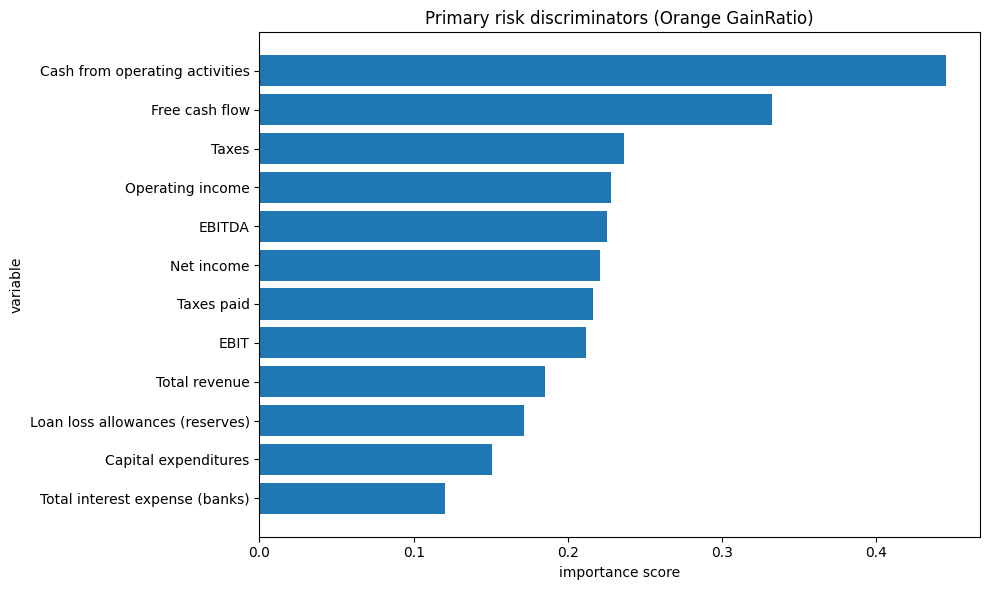

In [67]:
# Orange visibility view: rank + plot primary risk discriminators
# Uses Snorkel-predicted phase labels and excludes abstain (-1) rows.

import matplotlib.pyplot as plt

work = df_out[df_out["phase_pred"].isin([0, 1, 2, 3])].copy()
X = work[SCHEMA_COLS]
y = work["phase_pred"].astype(int)

try:
    import Orange

    attrs = [Orange.data.ContinuousVariable(c) for c in SCHEMA_COLS]
    class_var = Orange.data.DiscreteVariable(
        "phase_pred", values=[PHASES[i] for i in [0, 1, 2, 3]]
    )
    domain = Orange.data.Domain(attrs, class_var)

    orange_table = Orange.data.Table.from_numpy(
        domain,
        X.to_numpy(dtype=float),
        y.to_numpy(dtype=int),
    )

    _ = Orange.classification.TreeLearner(max_depth=4, min_samples_leaf=5)(orange_table)

    score_model = Orange.preprocess.score.GainRatio()
    rank_df = pd.DataFrame(
        {
            "variable": SCHEMA_COLS,
            "score": [float(score_model(orange_table, i)) for i in range(len(SCHEMA_COLS))],
            "metric": "Orange GainRatio",
        }
    ).sort_values("score", ascending=False)

    print("Orange view: top variables by GainRatio")

except ImportError:
    from sklearn.tree import DecisionTreeClassifier

    clf = DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, random_state=7)
    clf.fit(X, y)

    rank_df = pd.DataFrame(
        {
            "variable": SCHEMA_COLS,
            "score": clf.feature_importances_,
            "metric": "sklearn feature_importance",
        }
    ).sort_values("score", ascending=False)

    print("Orange not installed; showing sklearn decision-tree importance instead")

# Show ranking table + bar chart for quick visibility
rank_top = rank_df.head(12).reset_index(drop=True)
display(rank_top)

plt.figure(figsize=(10, 6))
plt.barh(rank_top["variable"][::-1], rank_top["score"][::-1])
plt.title(f"Primary risk discriminators ({rank_top['metric'].iloc[0]})")
plt.xlabel("importance score")
plt.ylabel("variable")
plt.tight_layout()
plt.show()


In [68]:
from Orange.classification.rules import CN2Learner

# Train Orange rule learner
cn2 = CN2Learner()
rule_model = cn2(orange_table)

# Print learned rules
print(f"Total rules: {len(rule_model.rule_list)}")
for i, rule in enumerate(rule_model.rule_list, 1):
    print(f"{i:02d}. {rule}")


Total rules: 50
01. IF Cash from operating activities>=142.96 AND Net income>=172.44 THEN phase_pred=expansion 
02. IF Operating income>=272.16 AND Net income>=217.95 THEN phase_pred=slowdown 
03. IF Net income<=34.81 AND Operating income>=89.22 THEN phase_pred=contraction 
04. IF Net income<=28.9 AND Operating income>=88.13 THEN phase_pred=slowdown 
05. IF Net income<=34.81 AND Net income>=34.81 THEN phase_pred=slowdown 
06. IF Net income<=35.59 AND Net income>=35.59 THEN phase_pred=slowdown 
07. IF Operating income<=86.76 AND Operating income>=86.76 THEN phase_pred=slowdown 
08. IF Operating income<=94.32 AND Operating income>=94.32 THEN phase_pred=slowdown 
09. IF Operating income<=94.9 AND Operating income>=94.9 THEN phase_pred=slowdown 
10. IF Operating income<=97.17 AND Operating income>=97.17 THEN phase_pred=slowdown 
11. IF Operating income<=97.83 AND Operating income>=97.83 THEN phase_pred=slowdown 
12. IF Operating income<=98.13 AND Operating income>=98.13 THEN phase_pred=slo

In [69]:
# define entity series here
if "statement" in df_out.columns:
    _entity_series = df_out["statement"].astype(str)
else:
    _entity_series = df_out.index.astype(str)

kg_rows = pd.DataFrame(
    {
        "entity_id": _entity_series,
        "role_name": df_out["phase_pred_name"].astype(str),
        "confidence": pd.to_numeric(df_out["pred_confidence"], errors="coerce"),
    }
)

# --- policy: what is allowed into KG ---
MIN_CONFIDENCE = 0.80
ALLOWED_PHASES = {"expansion", "recovery", "slowdown", "contraction"}

# Optional: if you tagged rows with a chosen rule id, keep only approved rules
# (example IDs from your reviewed clean_rules_df)
USE_RULE_ALLOWLIST = False
APPROVED_RULE_IDS = {1, 2, 17, 25, 32, 43, 45}  # update after manual review

kg_rows = pd.DataFrame(
    {
        "entity_id": _entity_series.astype(str),
        "role_name": df_out["phase_pred_name"].astype(str),
        "confidence": pd.to_numeric(df_out["pred_confidence"], errors="coerce"),
        # "rule_id": df_out["rule_id"],  # include only if you have this column
    }
)

kg_rows = (
    kg_rows
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=["entity_id", "role_name", "confidence"])
)

# keep valid labels only
kg_rows = kg_rows[kg_rows["role_name"].isin(ALLOWED_PHASES)]

# keep high-confidence predictions only
kg_rows = kg_rows[kg_rows["confidence"] >= MIN_CONFIDENCE] # use debug; goes to 0 on this line

# optional rule-based allowlist
if USE_RULE_ALLOWLIST and "rule_id" in kg_rows.columns:
    kg_rows = kg_rows[kg_rows["rule_id"].isin(APPROVED_RULE_IDS)]

kg_rows["entity_id"] = kg_rows["entity_id"].str.slice(0, 300)

print(f"Rows allowed for KG write: {len(kg_rows)}")

Rows allowed for KG write: 0


In [70]:

# Optional: write predicted phase as Role nodes into Neo4j KG.
# Enable only when NEO4J_URI / NEO4J_USERNAME / NEO4J_PASSWORD are set.
WRITE_ROLES_TO_NEO4J = False

if WRITE_ROLES_TO_NEO4J:
    import os
    from langchain_community.graphs import Neo4jGraph

    graph = Neo4jGraph(
        url=os.environ["NEO4J_URI"],
        username=os.environ["NEO4J_USERNAME"],
        password=os.environ["NEO4J_PASSWORD"],
    )

    # Use statement text as entity id and phase prediction as role.
    if "statement" in df_out.columns:
        _entity_series = df_out["statement"].astype(str)
    else:
        _entity_series = df_out.index.astype(str)

    kg_rows = pd.DataFrame(
        {
            "entity_id": _entity_series,
            "role_name": df_out["phase_pred_name"].astype(str),
            "confidence": pd.to_numeric(df_out["pred_confidence"], errors="coerce"),
        }
    )
    kg_rows = kg_rows.replace([np.inf, -np.inf], np.nan).dropna(subset=["entity_id", "role_name", "confidence"])
    kg_rows = kg_rows[kg_rows["role_name"].isin([PHASES[i] for i in [0, 1, 2, 3]])].copy()
    kg_rows["entity_id"] = kg_rows["entity_id"].str.slice(0, 300)

    graph.query("CREATE CONSTRAINT entity_id IF NOT EXISTS FOR (e:Entity) REQUIRE e.id IS UNIQUE")
    graph.query("CREATE CONSTRAINT role_name IF NOT EXISTS FOR (r:Role) REQUIRE r.name IS UNIQUE")

    q_upsert_roles = """
    UNWIND $rows AS row
    MERGE (e:Entity {id: row.entity_id})
    ON CREATE SET e.created_at = datetime()
    SET e.updated_at = datetime(),
        e.source = 'snorkel_financial_cycle_schema_demo'

    MERGE (r:Role {name: row.role_name})

    MERGE (e)-[hr:HAS_ROLE]->(r)
    SET hr.confidence = toFloat(row.confidence),
        hr.method = 'snorkel_phase_pred',
        hr.updated_at = datetime()
    """

    graph.query(q_upsert_roles, {"rows": kg_rows.to_dict("records")})
    print(f"Upserted {len(kg_rows)} Entity-Role links to Neo4j.")

    verify = graph.query(
        """
        MATCH (e:Entity)-[hr:HAS_ROLE]->(r:Role)
        RETURN e.id AS entity, r.name AS role, hr.confidence AS confidence
        ORDER BY confidence DESC
        LIMIT 12
        """
    )
    display(pd.DataFrame(verify))